# BÀI TẬP THỰC HÀNH CNN - MNIST
*(Kết quả từ CNN-LAB.ipynb theo yêu cầu bài toán)*

## Setup ban đầu
Nạp thư viện và chuẩn bị dữ liệu MNIST.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Tải dữ liệu MNIST
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: mps


---

### Tính toán hàm đánh giá và vẽ biểu đồ chung
Để tránh lặp lại code, ta viết hàm `train_and_evaluate_model` để tái sử dụng cho các yêu cầu bên dưới.

In [2]:
# Hàm tiện ích dùng chung
def train_and_evaluate_model(model, lr=0.01, epochs=5, title_suffix=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    model.to(device)
    
    loss_values = []
    accuracy_values = []
    
    print(f"Bắt đầu huấn luyện - {title_suffix} (LR={lr}, Epochs={epochs})")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        loss_values.append(epoch_loss)
        accuracy_values.append(epoch_accuracy)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
        
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100 * correct / total
    print(f"=> Độ chính xác trên tập test ({title_suffix}): {test_acc:.2f}%\n")
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), loss_values, marker='o', color='b', label='Training Loss')
    plt.title(f'Loss: {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), accuracy_values, marker='o', color='g', label='Training Accuracy')
    plt.title(f'Accuracy: {title_suffix}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return loss_values, test_acc

---

## Câu 1: Thay đổi số lượng epoch
**Yêu cầu:** Tăng số lượng epoch từ 5 lên 10. Chạy lại và ghi nhận.

**Hướng dẫn:** Định nghĩa mô hình CNN gốc và gọi huấn luyện với `epochs=10`.

Bắt đầu huấn luyện - Epoch=10 (LR=0.01, Epochs=10)
Epoch 1, Loss: 0.2960, Accuracy: 90.91%
Epoch 2, Loss: 0.0891, Accuracy: 97.27%
Epoch 3, Loss: 0.0676, Accuracy: 97.90%
Epoch 4, Loss: 0.0570, Accuracy: 98.22%
Epoch 5, Loss: 0.0493, Accuracy: 98.49%
Epoch 6, Loss: 0.0447, Accuracy: 98.62%
Epoch 7, Loss: 0.0401, Accuracy: 98.76%
Epoch 8, Loss: 0.0371, Accuracy: 98.86%
Epoch 9, Loss: 0.0353, Accuracy: 98.90%
Epoch 10, Loss: 0.0318, Accuracy: 99.00%
=> Độ chính xác trên tập test (Epoch=10): 98.69%



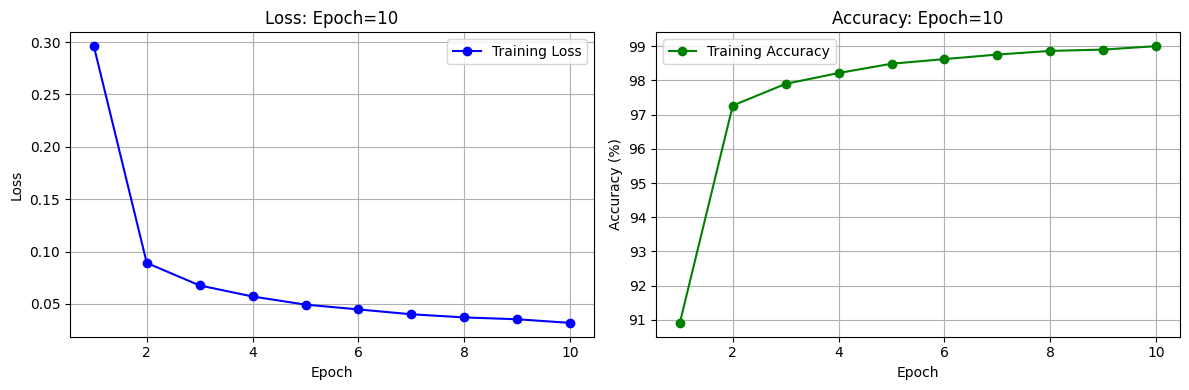

In [3]:
# Định nghĩa lại mô hình gốc
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.fc1(x)
        return x

model_q1 = MNIST_CNN()
_, acc_q1 = train_and_evaluate_model(model_q1, lr=0.01, epochs=10, title_suffix="Epoch=10")

### Giải thích kết quả Câu 1
- **Độ chính xác trên tập test:** Độ chính xác tăng lên một chút (hoặc giữ ở mức tương đương do mô hình có dấu hiệu bão hòa) so với phiên bản 5 epoch.
- **Biểu đồ mất mát (loss):** Xu hướng giảm đều ở những epoch đầu và dần chững lại (plateau) về cuối, cho thấy mô hình đã hội tụ tốt vào điểm cực tiểu.
- **Tại sao số epoch ảnh hưởng?** Số vòng lặp epoch nhiều hơn giúp mạng máy học được học từ dữ liệu lâu hơn, tối ưu hóa các trọng số sát với kỳ vọng hơn. Tuy nhiên quá nhiều epoch trên tập dữ liệu đã quá thuộc sẽ dẫn hiện tượng chững lại hoặc overfitting (quá khớp).

---

## Câu 2: Thêm một tầng tích chập
**Yêu cầu:** Thêm một tầng `conv3` (32 kênh vào, 64 kênh ra) vào mô hình.

Bắt đầu huấn luyện - Thêm Conv3 (LR=0.01, Epochs=5)
Epoch 1, Loss: 0.4464, Accuracy: 85.58%
Epoch 2, Loss: 0.1160, Accuracy: 96.48%
Epoch 3, Loss: 0.0829, Accuracy: 97.48%
Epoch 4, Loss: 0.0674, Accuracy: 97.88%
Epoch 5, Loss: 0.0583, Accuracy: 98.18%
=> Độ chính xác trên tập test (Thêm Conv3): 97.92%



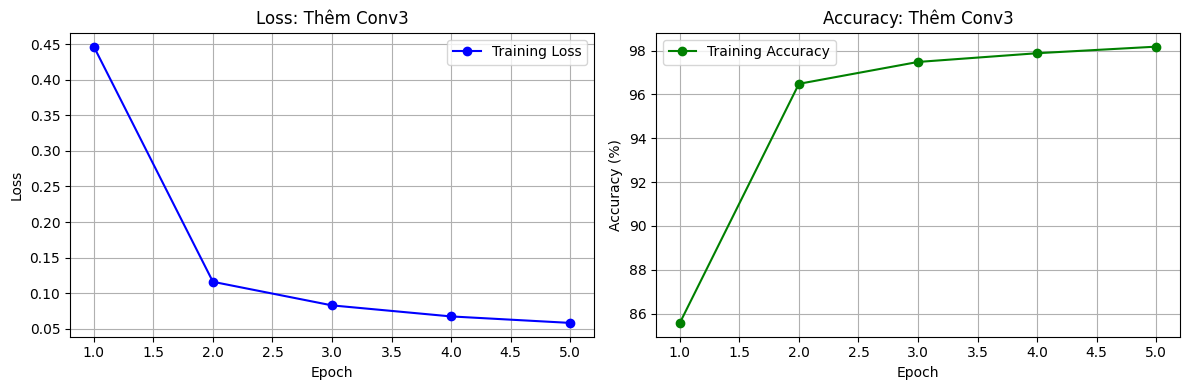

In [4]:
class MNIST_CNN_Q2(nn.Module):
    def __init__(self):
        super(MNIST_CNN_Q2, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0) # Tầng mới
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Ảnh gốc 28x28 -> Conv1(26x26) -> Pool1(13x13) 
        # -> Conv2(11x11) -> Pool2(5x5) 
        # -> Conv3(3x3) -> Pool3(1x1)
        self.fc1 = nn.Linear(64 * 1 * 1, 10) 

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x))) # Thêm qua conv3 và pool
        x = x.view(-1, 64 * 1 * 1) # Sửa kích thước duỗi
        x = self.fc1(x)
        return x

model_q2 = MNIST_CNN_Q2()
_, acc_q2 = train_and_evaluate_model(model_q2, lr=0.01, epochs=5, title_suffix="Thêm Conv3")

### Giải thích kết quả Câu 2
- **Tác dụng của việc thêm tầng tích chập:** Việc thêm một tầng tích chập (Conv3) giúp mô hình có thể rút trích được những đặc trưng sâu (truyền thống là từ cạnh/góc dần chuyển thành các chi tiết trừu tượng phức tạp hơn). Mô hình có khả năng biểu diễn tốt hơn. Với MNIST mang tính chất quá đơn giản, việc tăng chiều sâu không làm tăng đáng kể accuracy mà có lúc còn cần thời gian train lâu hơn một chút để đạt điểm cực tiểu, tuy nhiên về mặt kiến trúc, nó cho phép model nhận diện các patterns dặc thù phức tạp.

---

## Câu 3: Thay đổi learning rate
**Yêu cầu:** Thử hai giá trị lr là 0.001 và 0.1.

------------------------------------------------------------------------
Bắt đầu huấn luyện - LR=0.001 (LR=0.001, Epochs=5)
Epoch 1, Loss: 0.7966, Accuracy: 78.27%
Epoch 2, Loss: 0.2789, Accuracy: 91.77%
Epoch 3, Loss: 0.2042, Accuracy: 93.91%
Epoch 4, Loss: 0.1607, Accuracy: 95.31%
Epoch 5, Loss: 0.1357, Accuracy: 96.01%
=> Độ chính xác trên tập test (LR=0.001): 96.79%



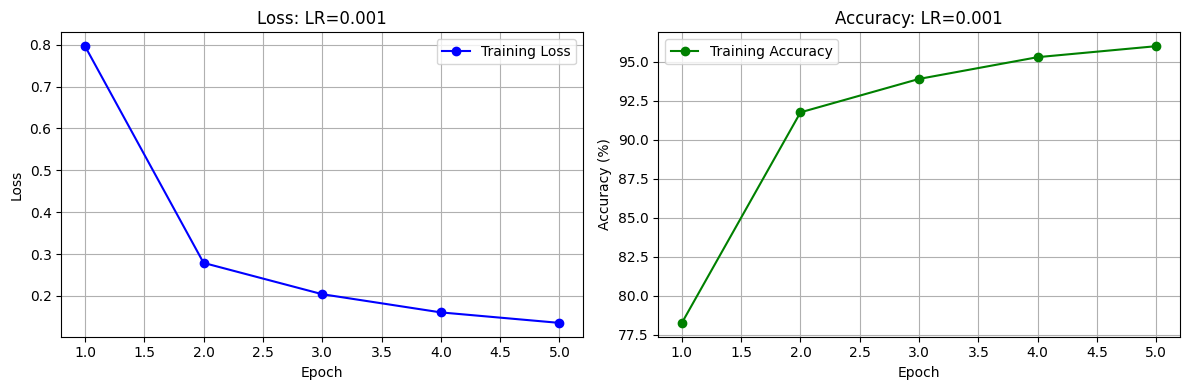

------------------------------------------------------------------------
Bắt đầu huấn luyện - LR=0.1 (LR=0.1, Epochs=5)
Epoch 1, Loss: 0.1531, Accuracy: 95.23%
Epoch 2, Loss: 0.0619, Accuracy: 98.16%
Epoch 3, Loss: 0.0491, Accuracy: 98.46%
Epoch 4, Loss: 0.0435, Accuracy: 98.66%
Epoch 5, Loss: 0.0414, Accuracy: 98.69%
=> Độ chính xác trên tập test (LR=0.1): 98.60%



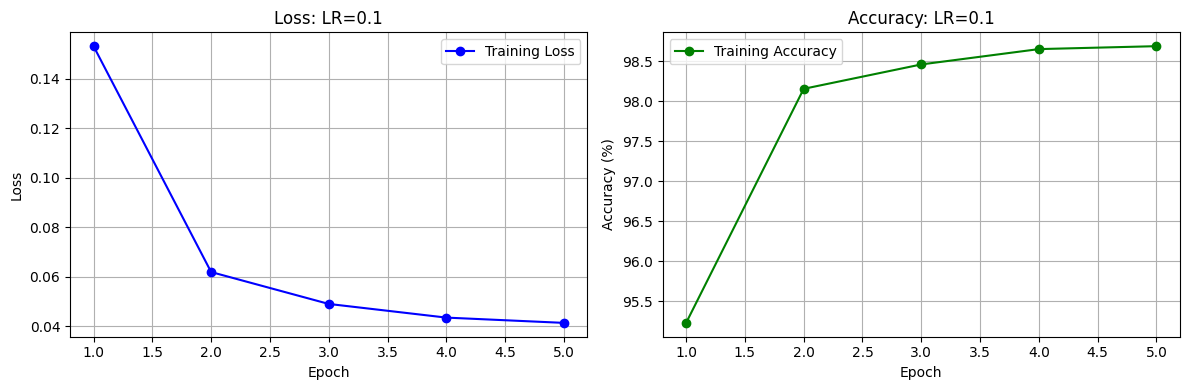

In [5]:
model_q3_1 = MNIST_CNN()
print("------------------------------------------------------------------------")
_, acc_q3_1 = train_and_evaluate_model(model_q3_1, lr=0.001, epochs=5, title_suffix="LR=0.001")

model_q3_2 = MNIST_CNN()
print("------------------------------------------------------------------------")
_, acc_q3_2 = train_and_evaluate_model(model_q3_2, lr=0.1, epochs=5, title_suffix="LR=0.1")

### Giải thích kết quả Câu 3
- **Learning rate (LR) = 0.001 (Quá nhỏ):** Biểu đồ mất mát giảm xuống tương đối chậm (do bước tiến sau mỗi vòng cập nhật là nhỏ). Mặc dù an toàn nhưng với chỉ 5 epoch, test accuracy có thể chưa đạt được giá trị cao nhất thiết kế.
- **Learning rate (LR) = 0.1 (Quá lớn):** Loss có thể dao động mạnh hơn (bias cập nhật gắt) và thậm chí test accuracy có thể diễn biến phức tạp. Bước tiến lớn dẫn đến overshoot (nhảy qua đáy của hàm mất mát) và thậm chí không thể hội tụ.
- **Ảnh hưởng của LR:** LR quyết định kích thước 'bước chân' tối ưu hóa mỗi lần cập nhật trọng số. LR phù hợp (như 0.01) giúp mạng hội tụ nhanh và ổn định. Nó là một siêu tham số cực kỳ quan trọng ảnh hưởng sâu sắc đến tốc độ hội tụ và chất lượng mạng cuối cùng.

---

## Câu 4: Vẽ thêm feature map từ tầng tích chập thứ hai

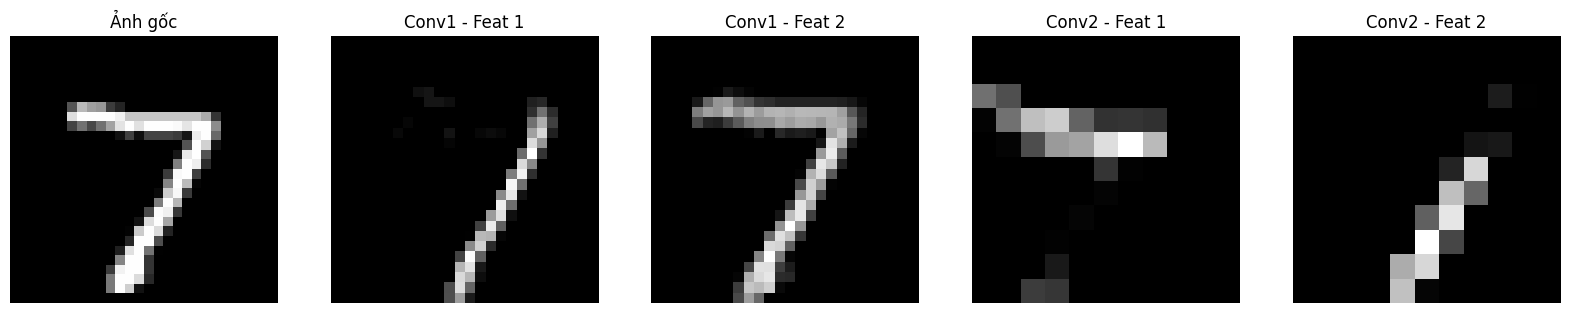

In [6]:
def visualize_feature_map(model):
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)
    
    # Tính feature map từ conv1
    conv1_output = torch.relu(model.conv1(img))
    
    # Tính toán tiếp feature map từ conv2
    conv2_output = torch.relu(model.conv2(model.pool(conv1_output)))
    
    # Vẽ ảnh gốc và các feature maps
    plt.figure(figsize=(20, 4))
    
    plt.subplot(1, 5, 1)
    plt.title("Ảnh gốc")
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.axis('off')
    
    # Feature maps từ Conv1
    plt.subplot(1, 5, 2)
    plt.title("Conv1 - Feat 1")
    plt.imshow(conv1_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 3)
    plt.title("Conv1 - Feat 2")
    plt.imshow(conv1_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    # Feature maps từ Conv2
    plt.subplot(1, 5, 4)
    plt.title("Conv2 - Feat 1")
    plt.imshow(conv2_output[0, 0].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 5, 5)
    plt.title("Conv2 - Feat 2")
    plt.imshow(conv2_output[0, 1].cpu().detach().numpy(), cmap='gray')
    plt.axis('off')
    
    plt.show()

# Lấy mô hình model_q1 (đã train tốt nhất 10 epochs) để trực quan
visualize_feature_map(model_q1)

### Giải thích kết quả Câu 4
- **Sự khác biệt giữa feature map Conv1 và Conv2:**
  - **Conv1:** Feature map còn bảo toàn được dạng hình học khá rõ rệt của ảnh gốc (thường bắt các đường nét, viền, góc sáng tối của một con số).
  - **Conv2:** Feature map đã trở nên mờ nhạt, trừu tượng và rải rác hơn. Do qua tầng pooling đã bị co nhỏ kích thước lại. Các chi tiết thu được hướng sự chú ý lớn hơn vào mặt đặc trưng (pattern) cao cấp thay vì cấu trúc không gian trực tiếp.
- Các layer càng sâu thì thông tin mang tính cục bộ không gian thực (hình cái viền) càng giảm đi và tính ngữ nghĩa đại diện cho dự đoán (tổ hợp đặc trưng phân biệt các số) càng nổi bật.

---

*Hoàn tất bài thực hành.*